# Context & Background

# Pain Point in Industry

# ML Solution Overview

# Data Sources

# Model Workflow

# Key Results

# Business Value

# Limitations

# Future Enhancements

# Closing Remarks

## Context & Background

### Why This Project
- Most fraud discussions focus on **banking or financial fraud**.
- **Insurance fraud is often overlooked**.
- Fraudsters submit **false or exaggerated insurance claims**.
- This leads to **large financial losses for insurance companies**.

### Motivation
- Insurance fraud is **hard to detect manually**.
- Healthcare claims involve **large amounts of data**.
- Fraud patterns are often **hidden in claim records**.

### Goal of the Project
- Analyze healthcare claim data.
- Identify **suspicious claim patterns**.
- Build a **machine learning model** to detect potential fraud.

### Expected Outcome
- Help detect **fraudulent claims earlier**.
- Reduce **financial losses for insurance companies**.
- Demonstrate how **data science can improve fraud detection**.


# DATA SOURCE:
https://www.kaggle.com/datasets/karthick11g/claim-fraud-detection
[Data Source: Claim Fraud Detection](https://www.kaggle.com/datasets/karthick11g/claim-fraud-detection)


# ABOUT DATA SET:


| Column | Full Form | Description | Data Type | Why Used in Fraud Detection | Example Values |
|------|------|------|------|------|------|
| `InscClaimAmtReimbursed` | Insurance Claim Amount Reimbursed | Amount paid by the insurer to the healthcare provider for a claim | int64 | **Key fraud signal** – unusually high claims may indicate upcoding or unnecessary procedures | 26000, 5000, 102000 |
| `DeductibleAmtPaid` | Deductible Amount Paid | Portion of the claim paid by the patient before insurance coverage begins | float64 | Unrealistic deductible values may indicate suspicious billing | 0, 1068 |
| `AttendingPhysician` | Attending Physician ID | Unique identifier of the physician responsible for treatment | object | Helps detect physicians frequently associated with fraudulent claims | PHYS1234 |
| `Gender` | Beneficiary Gender | Gender of the patient (1 = Male, 2 = Female) | int64 | Used for demographic risk adjustment | 1, 2 |
| `Race` | Beneficiary Race | Encoded race category of the beneficiary | int64 | Helps analyze healthcare utilization patterns | 1–5 |
| `RenalDiseaseIndicator` | End-Stage Renal Disease Indicator | Indicates whether the beneficiary has ESRD | object | ESRD patients require expensive treatments such as dialysis | Y, N |
| `NoOfMonths_PartACov` | Number of Months Part A Coverage | Number of months the beneficiary had Medicare Part A coverage during the year | int64 | Helps verify claim eligibility and coverage completeness | 12 |
| `ChronicCond_Alzheimer` | Alzheimer’s Disease | Indicates presence of Alzheimer’s disease | int64 | Used for long-term care risk estimation | 0, 1 |
| `ChronicCond_Heartfailure` | Heart Failure | Indicates presence of heart failure | int64 | High-cost cardiac condition | 0, 1 |
| `ChronicCond_KidneyDisease` | Chronic Kidney Disease | Indicates presence of kidney disease | int64 | May lead to expensive treatments such as dialysis | 0, 1 |
| `ChronicCond_Cancer` | Cancer | Indicates presence of cancer | int64 | Cancer treatment leads to very high reimbursements | 0, 1 |
| `ChronicCond_ObstrPulmonary` | Chronic Obstructive Pulmonary Disease (COPD) | Indicates presence of COPD | int64 | Long-term respiratory treatment increases costs | 0, 1 |
| `ChronicCond_Depression` | Depression | Indicates presence of depression | int64 | Mental health conditions increase healthcare utilization | 0, 1 |
| `ChronicCond_Diabetes` | Diabetes | Indicates presence of diabetes | int64 | Diabetes often leads to multiple costly complications | 0, 1 |
| `ChronicCond_IschemicHeart` | Ischemic Heart Disease | Indicates presence of coronary artery disease | int64 | Often associated with hospitalization and high treatment costs | 0, 1 |
| `ChronicCond_Osteoporasis` | Osteoporosis | Indicates presence of osteoporosis | int64 | Associated with fracture risk and long-term care | 0, 1 |
| `ChronicCond_rheumatoidarthritis` | Rheumatoid Arthritis / Osteoarthritis | Indicates presence of joint disease | int64 | Chronic joint diseases increase healthcare visits | 0, 1 |
| `ChronicCond_stroke` | Stroke / Transient Ischemic Attack | Indicates history of stroke | int64 | Stroke patients require long-term medical care | 0, 1 |
| `IPAnnualReimbursementAmt` | Inpatient Annual Reimbursement Amount | Total yearly reimbursement for inpatient hospital services | int64 | Extremely high inpatient spending may indicate fraud | 36000, 131140 |
| `IPAnnualDeductibleAmt` | Inpatient Annual Deductible Amount | Total deductible paid for inpatient services in a year | int64 | Used to validate claim consistency | 3204, 2136 |
| `OPAnnualReimbursementAmt` | Outpatient Annual Reimbursement Amount | Total yearly reimbursement for outpatient services | int64 | Overutilization of outpatient services may signal fraud | 60, 1650 |
| `OPAnnualDeductibleAmt` | Outpatient Annual Deductible Amount | Total deductible paid for outpatient services in a year | int64 | Helps verify patient cost sharing | 70, 80 |
| `PotentialFraud` | Potential Fraud Label | Indicates whether the provider is flagged as potentially fraudulent | object | **Target variable** used for fraud detection models | Yes, No |


# Model Workflow¶

### Importing modules

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,roc_curve,accuracy_score,roc_auc_score,classification_report
import pickle
from scipy import stats
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
import math

#### Loading dataset

In [2]:

train = pd.read_csv('Datasets/Train-1542865627584.csv')
train_bene = pd.read_csv('Datasets/Train_Beneficiarydata-1542865627584.csv')
train_ip = pd.read_csv('Datasets/Train_Inpatientdata-1542865627584.csv')
train_op = pd.read_csv('Datasets/Train_Outpatientdata-1542865627584.csv')

test = pd.read_csv('Datasets/Test-1542969243754.csv')
test_bene = pd.read_csv('Datasets/Test_Beneficiarydata-1542969243754.csv')
test_ip = pd.read_csv('Datasets/Test_Inpatientdata-1542969243754.csv')
test_op = pd.read_csv('Datasets/Test_Outpatientdata-1542969243754.csv')

train_claims = pd.concat([train_ip, train_op], axis=0, ignore_index=True)
train_claims = pd.merge(train_claims, train_bene, on='BeneID', how='left')
train_full = pd.merge(train_claims, train, on='Provider', how='left')

test_claims = pd.concat([test_ip, test_op], axis=0, ignore_index=True)
test_claims = pd.merge(test_claims, test_bene, on='BeneID', how='left')
test_full = pd.merge(test_claims, test, on='Provider', how='left')

df = pd.concat([train_full, test_full], axis=0, ignore_index=True)

### Finding null values

In [3]:
df.isna().sum()*100/len(df)

BeneID                               0.000000
ClaimID                              0.000000
ClaimStartDt                         0.000000
ClaimEndDt                           0.000000
Provider                             0.000000
InscClaimAmtReimbursed               0.000000
AttendingPhysician                   0.267444
OperatingPhysician                  79.579096
OtherPhysician                      64.191620
AdmissionDt                         92.787661
ClmAdmitDiagnosisCode               73.867616
DeductibleAmtPaid                    0.157871
DischargeDt                         92.787661
DiagnosisGroupCode                  92.787661
ClmDiagnosisCode_1                   1.878740
ClmDiagnosisCode_2                  35.090823
ClmDiagnosisCode_3                  56.502062
ClmDiagnosisCode_4                  70.566304
ClmDiagnosisCode_5                  79.999798
ClmDiagnosisCode_6                  84.926247
ClmDiagnosisCode_7                  88.183154
ClmDiagnosisCode_8                

### Ignoring unwanted data resons are as mentioned below
| Category                    | Columns                                                        | Reason for Ignored                                                         |
| --------------------------- | ------------------------------------------------------------------------ | ---------------------------------------------------------------------------- |
| Identifier Columns          | `BeneID`, `ClaimID`, `Provider`                                          | Unique identifiers; do not provide meaningful analytical patterns            |
| Date Columns                | `ClaimStartDt`, `ClaimEndDt`, `AdmissionDt`, `DischargeDt`, `DOB`, `DOD` | Raw dates require feature engineering (e.g., age, duration)                  |
| Diagnosis & Procedure Codes | `ClmDiagnosisCode_*`, `ClmProcedureCode_*`, `DiagnosisGroupCode`         | High missing values and categorical medical codes requiring special encoding |
| Physician Columns           | `OperatingPhysician`, `OtherPhysician`                                   | Large percentage of missing data, reducing reliability                       |


In [4]:
### i
df=df[['InscClaimAmtReimbursed', 'AttendingPhysician','DeductibleAmtPaid', 'Gender', 'Race',
       'RenalDiseaseIndicator', 'ChronicCond_Alzheimer',
       'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease',
       'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary',
       'ChronicCond_Depression', 'ChronicCond_Diabetes',
       'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis',
       'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke',
       'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
       'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'PotentialFraud']]

####  droped the rows of nan values - we have more data its okey to remove columns

In [5]:
df.dropna(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 555813 entries, 0 to 558210
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   InscClaimAmtReimbursed           555813 non-null  int64  
 1   AttendingPhysician               555813 non-null  object 
 2   DeductibleAmtPaid                555813 non-null  float64
 3   Gender                           555813 non-null  int64  
 4   Race                             555813 non-null  int64  
 5   RenalDiseaseIndicator            555813 non-null  object 
 6   ChronicCond_Alzheimer            555813 non-null  int64  
 7   ChronicCond_Heartfailure         555813 non-null  int64  
 8   ChronicCond_KidneyDisease        555813 non-null  int64  
 9   ChronicCond_Cancer               555813 non-null  int64  
 10  ChronicCond_ObstrPulmonary       555813 non-null  int64  
 11  ChronicCond_Depression           555813 non-null  int64  
 12  Chronic

In [7]:
df.describe()

,InscClaimAmtReimbursed,DeductibleAmtPaid,Gender,Race,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
count,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000,555813.000000
mean,979.480005,78.427507,1.578801,1.254996,1.598737,1.410244,1.588849,1.848827,1.687803,1.565640,1.295137,1.241157,1.682417,1.689124,1.898613,5176.563484,565.913568,2277.858308,649.660449
std,3764.681292,274.028080,0.493752,0.717477,0.490154,0.491878,0.492043,0.358218,0.463390,0.495673,0.456105,0.427786,0.465537,0.462853,0.301840,11686.204691,1176.043376,3879.988651,1002.180273
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,-8000.000000,0.000000,-70.000000,0.000000
25%,40.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,460.000000,120.000000
50%,80.000000,0.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,0.000000,0.000000,1170.000000,340.000000
75%,300.000000,0.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,5640.000000,1068.000000,2590.000000,790.000000
max,125000.000000,1068.000000,2.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,161470.000000,38272.000000,102960.000000,13840.000000


In [8]:
df.head()

,InscClaimAmtReimbursed,AttendingPhysician,DeductibleAmtPaid,Gender,Race,RenalDiseaseIndicator,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,...,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud
0,26000,PHY390922,1068.0,1,1,0,1,2,1,2,...,1,1,2,1,1,36000,3204,60,70,Yes
1,5000,PHY318495,1068.0,1,1,0,1,2,1,2,...,1,1,2,1,1,36000,3204,60,70,No
2,5000,PHY372395,1068.0,1,1,0,1,2,1,2,...,1,1,2,1,1,36000,3204,60,70,No
3,5000,PHY369659,1068.0,2,2,0,2,1,1,2,...,1,2,2,1,1,5000,1068,250,320,No
4,10000,PHY379376,1068.0,2,1,Y,2,1,1,2,...,2,1,2,2,2,21260,2136,120,100,No


In [9]:
for col in df.columns:
    print("=" * 60)
    print(f"Column Name: {col}")
    print(f"Data Type : {df[col].dtype}")
    print("=" * 60)

    if df[col].dtype in ['int64', 'float64']:
        # Numerical column
        print("Descriptive Statistics:")
        print(f"Count : {df[col].count()}")
        print(f"Mean  : {df[col].mean()}")
        print(f"Std   : {df[col].std()}")
        print(f"Min   : {df[col].min()}")
        print(f"25%   : {df[col].quantile(0.25)}")
        print(f"50%   : {df[col].median()}")
        print(f"75%   : {df[col].quantile(0.75)}")
        print(f"Max   : {df[col].max()}")

    else:
        # Object / categorical column
        print("Descriptive Statistics:")
        print(f"Count  : {df[col].count()}")
        print(f"Unique : {df[col].nunique()}")
        print(f"Top    : {df[col].mode()[0]}")
        print("\nValue Counts:")
        print(df[col].value_counts(dropna=False))

    print("\n")


Column Name: InscClaimAmtReimbursed
Data Type : int64
Descriptive Statistics:
Count : 555813
Mean  : 979.4800049656989
Std   : 3764.6812919177123
Min   : 0
25%   : 40.0
50%   : 80.0
75%   : 300.0
Max   : 125000


Column Name: AttendingPhysician
Data Type : object
Descriptive Statistics:
Count  : 555813
Unique : 81953
Top    : PHY330576

Value Counts:
AttendingPhysician
PHY330576    2534
PHY350277    1628
PHY412132    1321
PHY423534    1223
PHY314027    1200
             ... 
PHY393772       1
PHY355350       1
PHY314062       1
PHY369635       1
PHY317658       1
Name: count, Length: 81953, dtype: int64


Column Name: DeductibleAmtPaid
Data Type : float64
Descriptive Statistics:
Count : 555813
Mean  : 78.42750709321301
Std   : 274.02808029868436
Min   : 0.0
25%   : 0.0
50%   : 0.0
75%   : 0.0
Max   : 1068.0


Column Name: Gender
Data Type : int64
Descriptive Statistics:
Count : 555813
Mean  : 1.5788007837168256
Std   : 0.4937518355467113
Min   : 1
25%   : 1.0
50%   : 2.0
75%   : 2.0
Ma

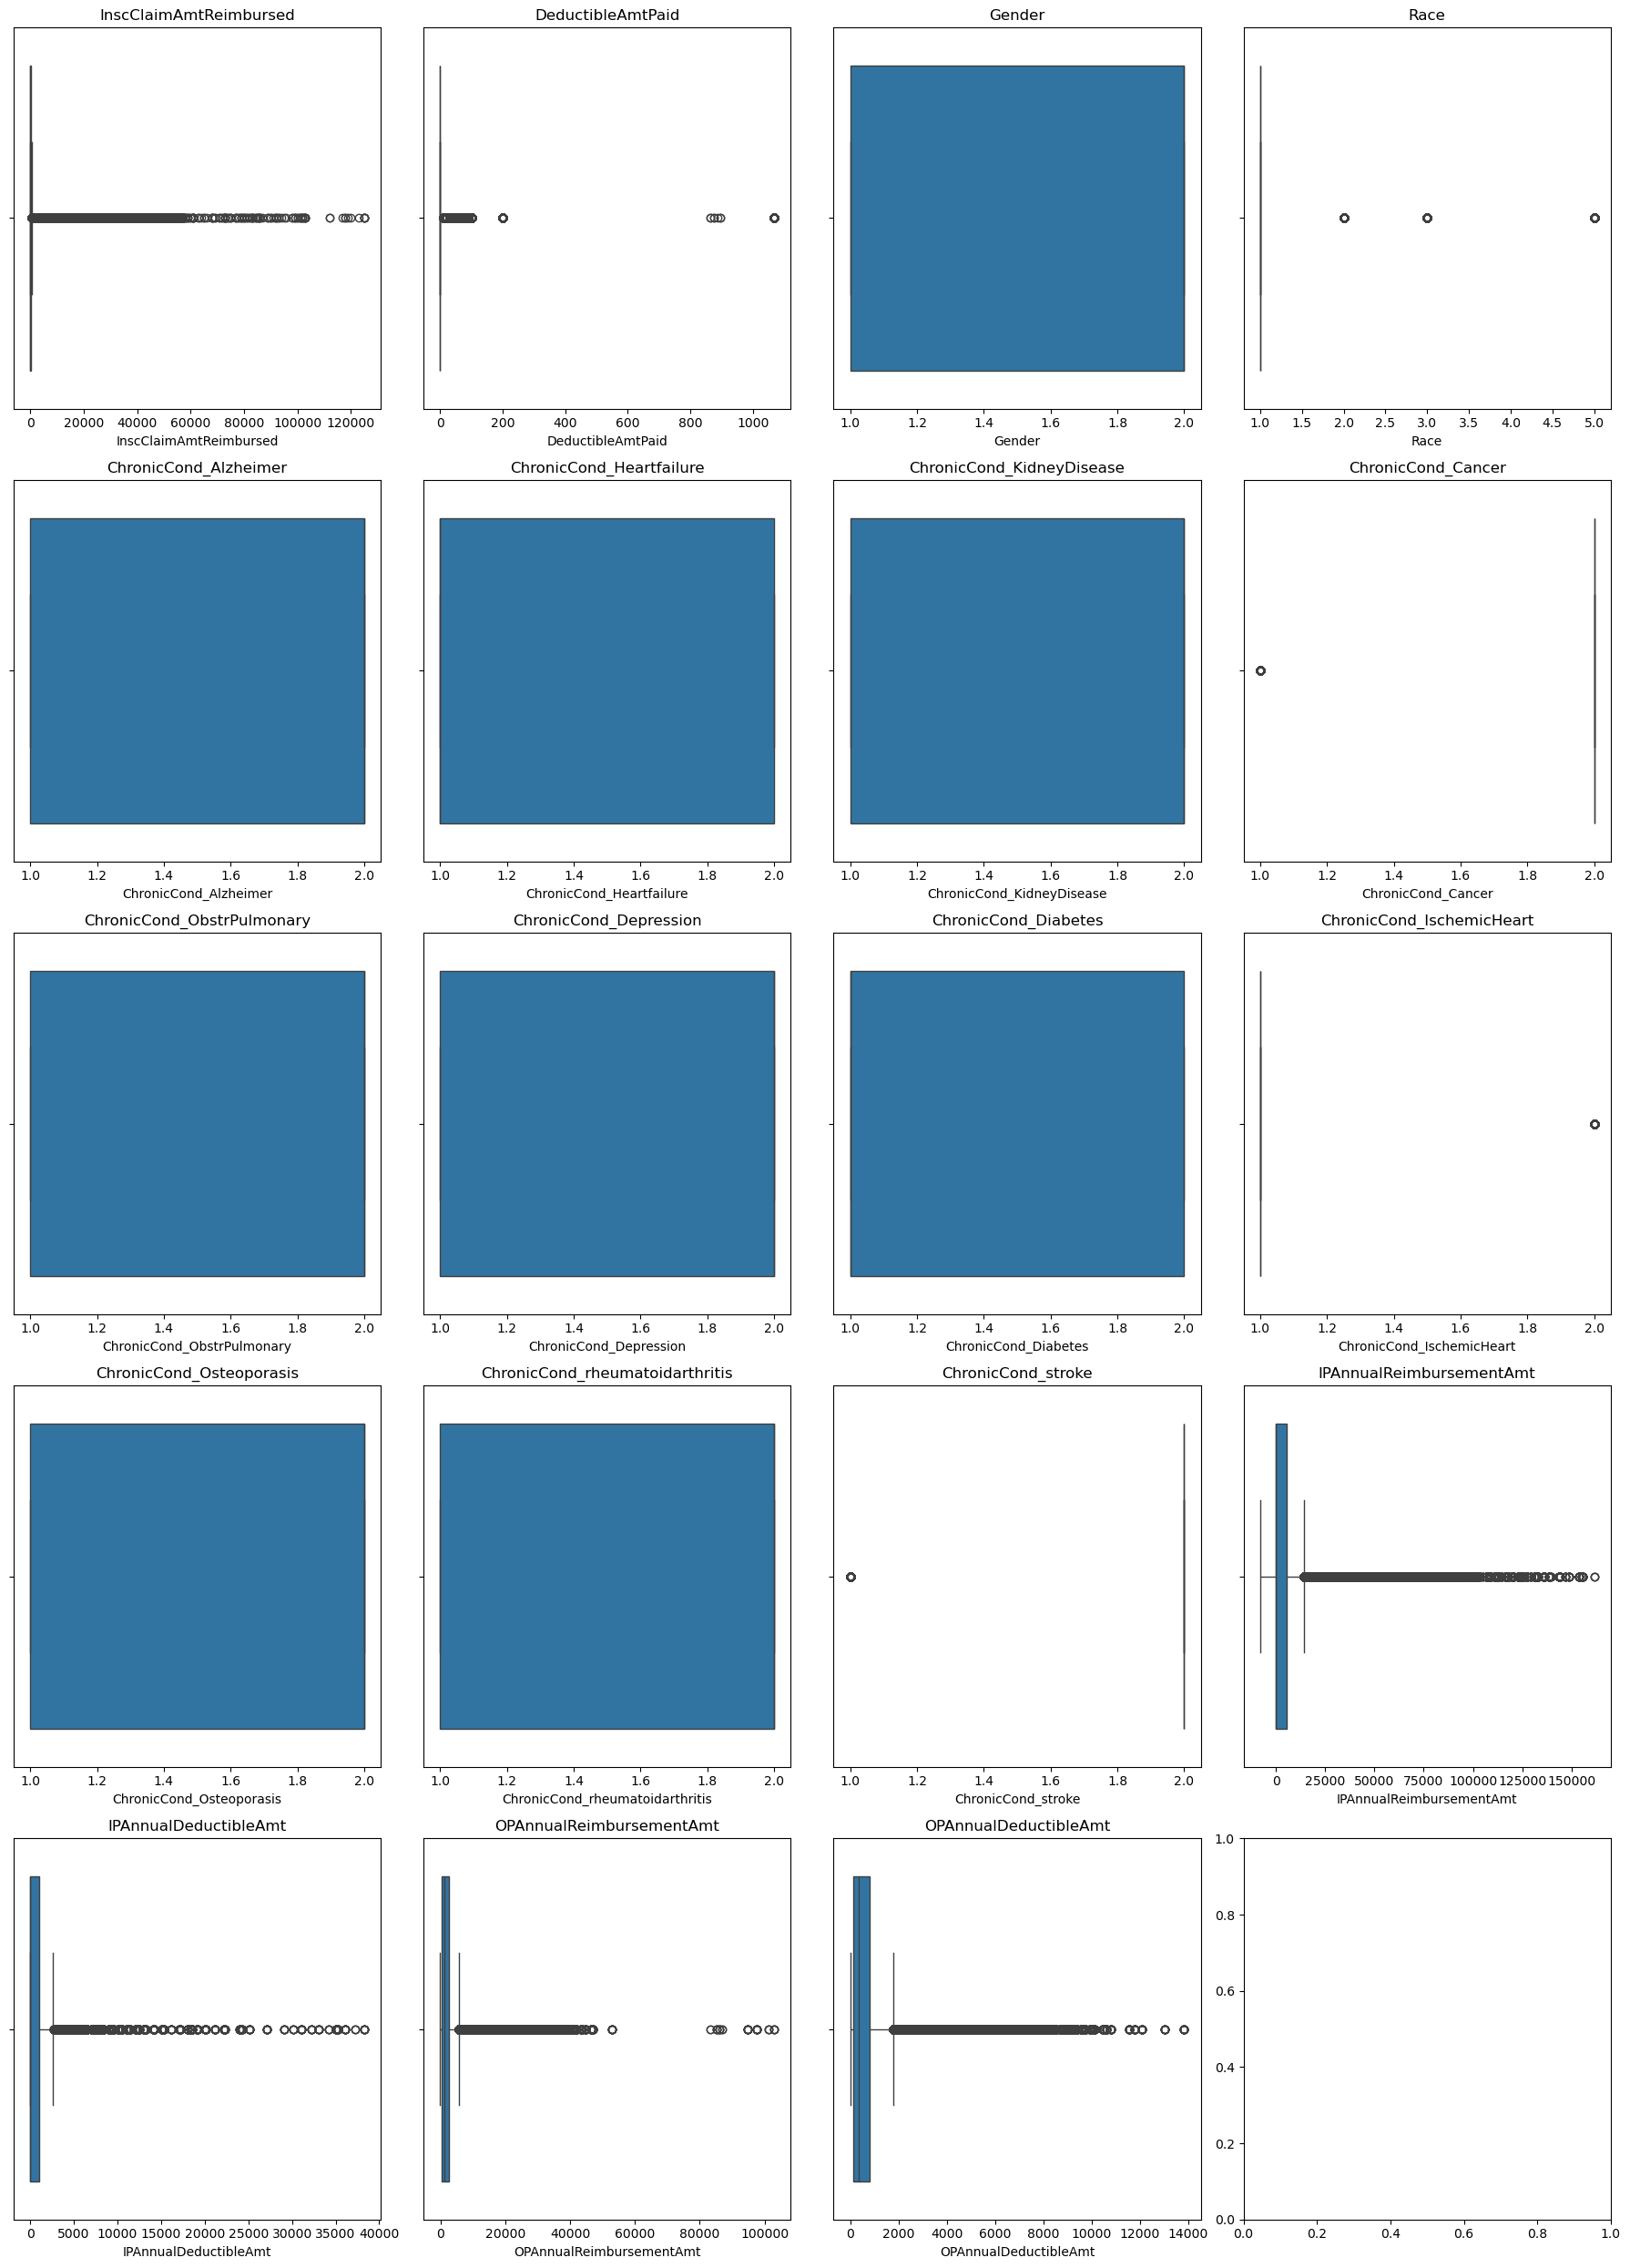

In [10]:

fig, axes = plt.subplots(5, 4, figsize=(18, 5 * 5))
axes = axes.flatten()

for i, col in enumerate(df.select_dtypes(exclude='object').columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    
plt.tight_layout()
plt.show()

### From above image
-> beware of the outliers 

Info of the all numerical columns


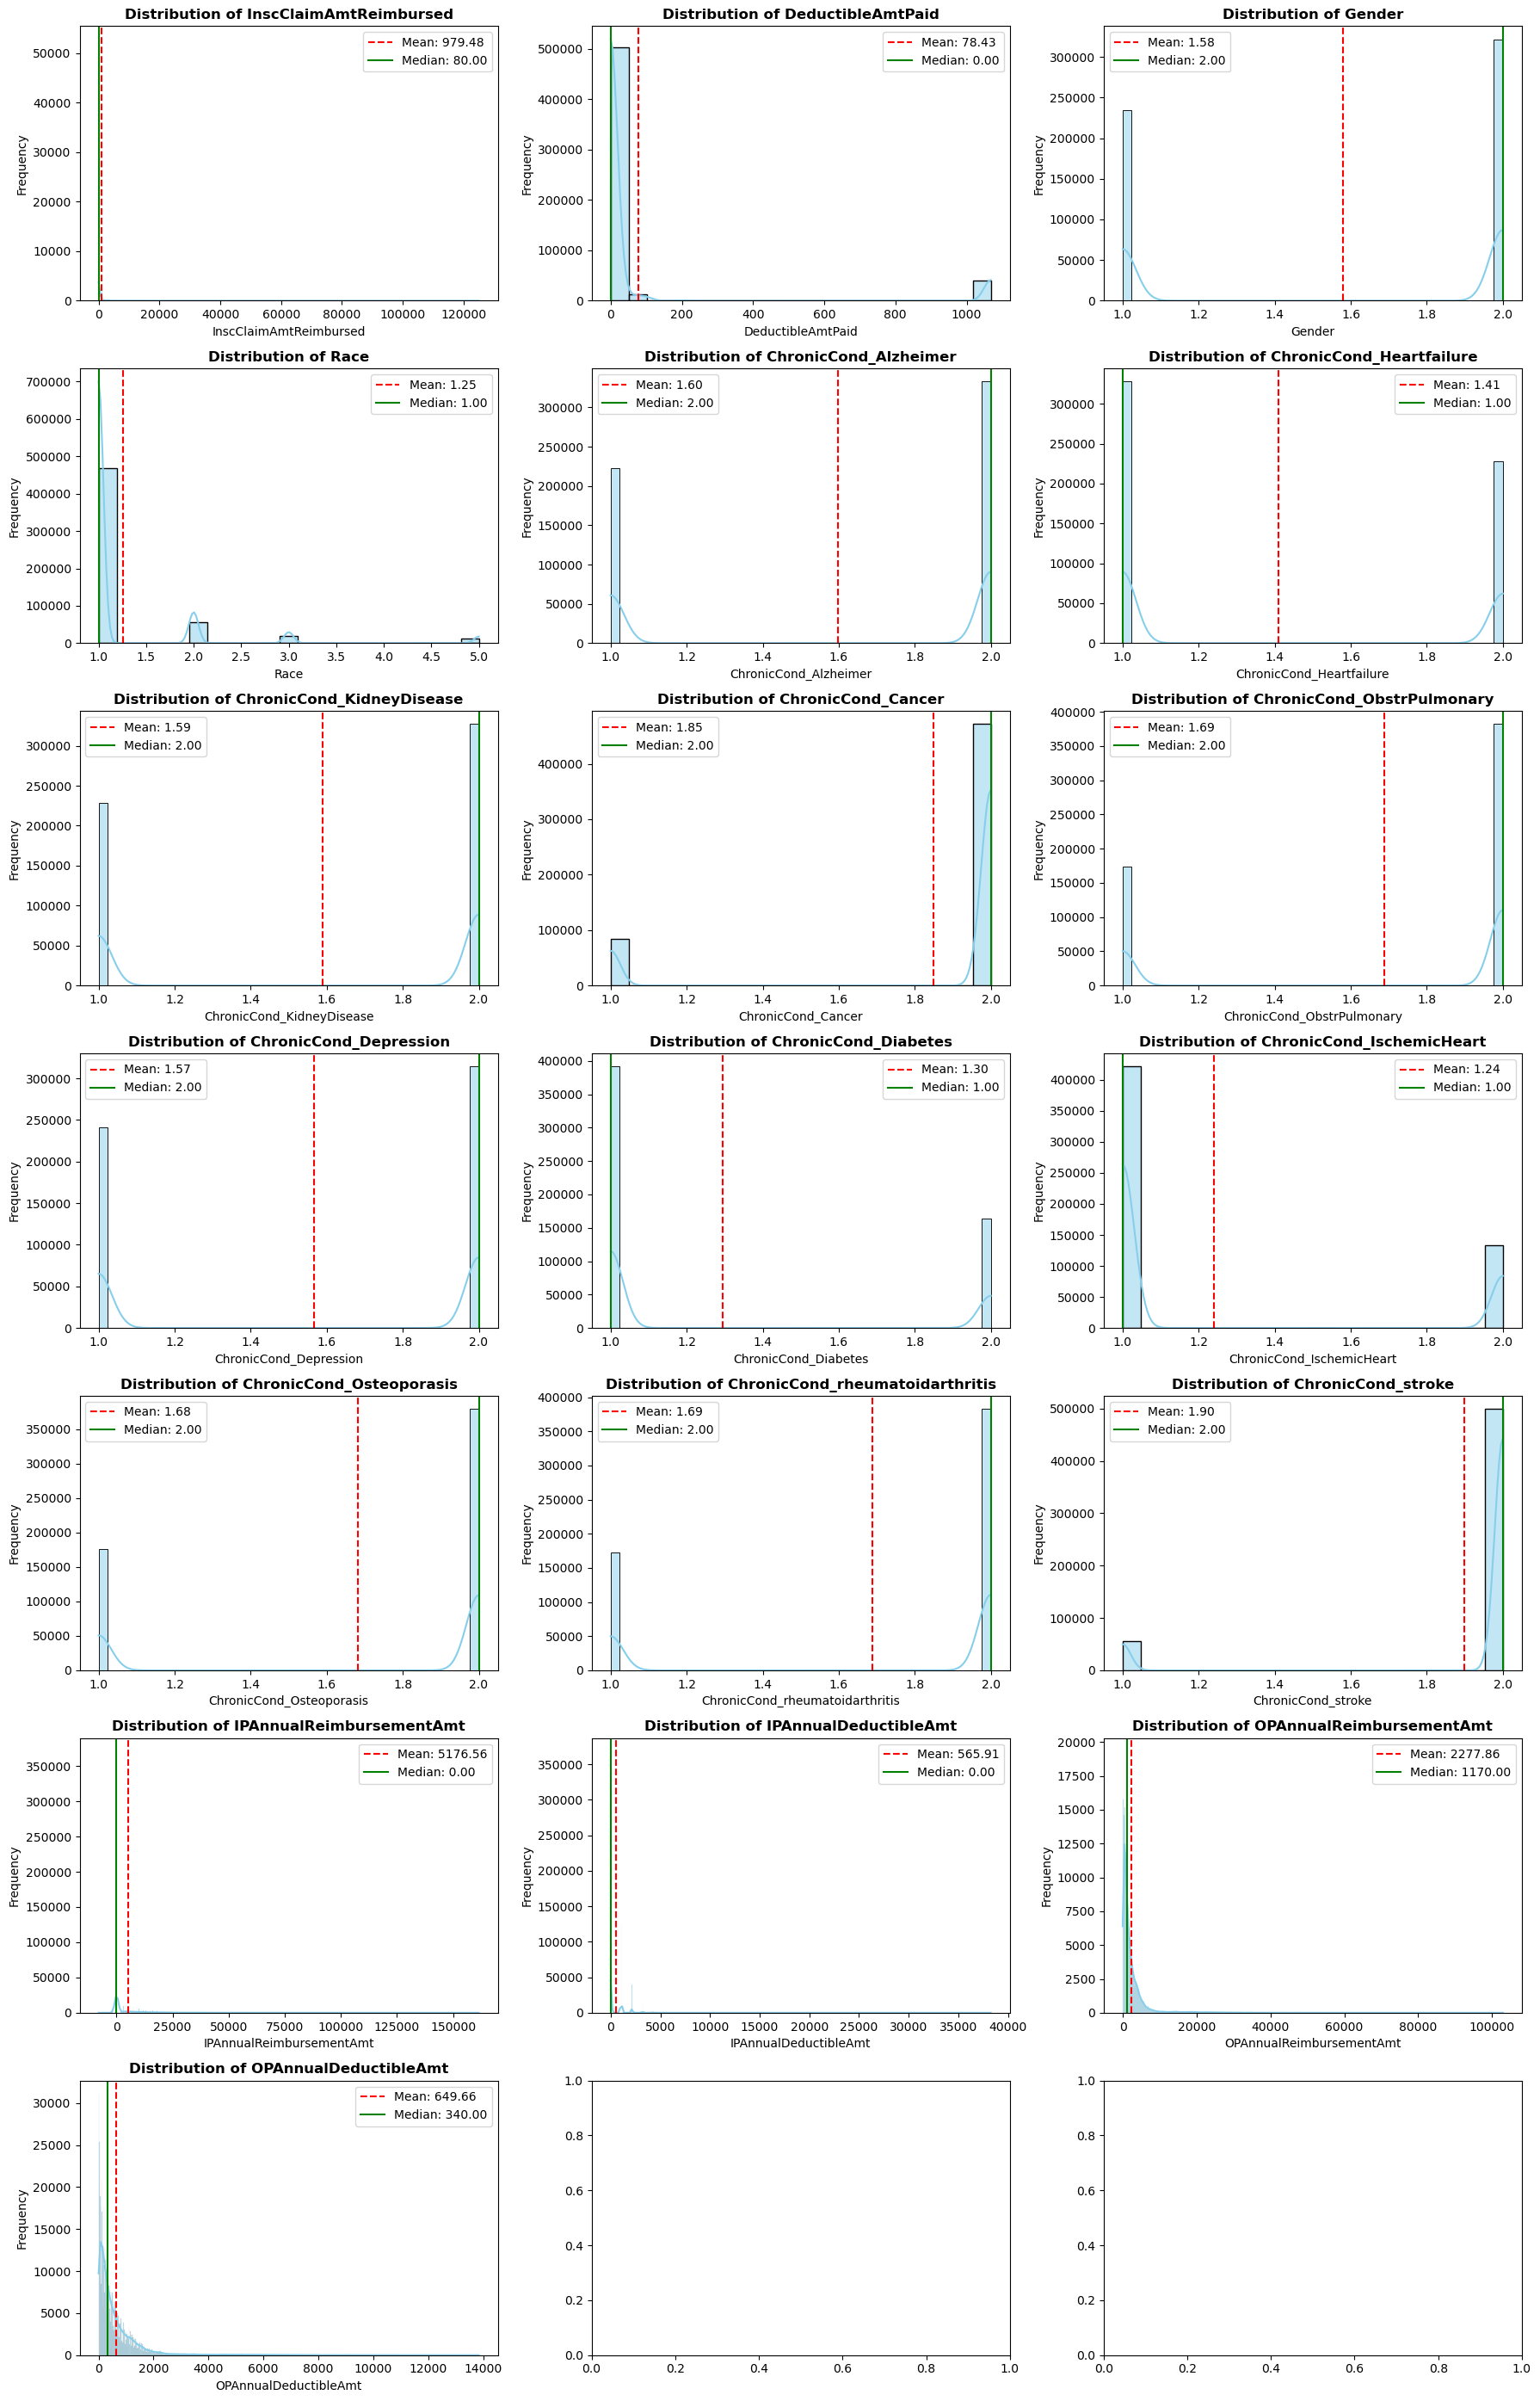

In [11]:
print("Info of the all numerical columns")
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

plot_cols = [col for col in df.select_dtypes(exclude='object').columns]
n_cols = len(plot_cols)

n_subplot_cols = 3
n_subplot_rows = math.ceil(n_cols / n_subplot_cols)
fig, axes = plt.subplots(n_subplot_rows, n_subplot_cols, figsize=(18, 4 * n_subplot_rows))
axes = axes.flatten()  

for i, col in enumerate(plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

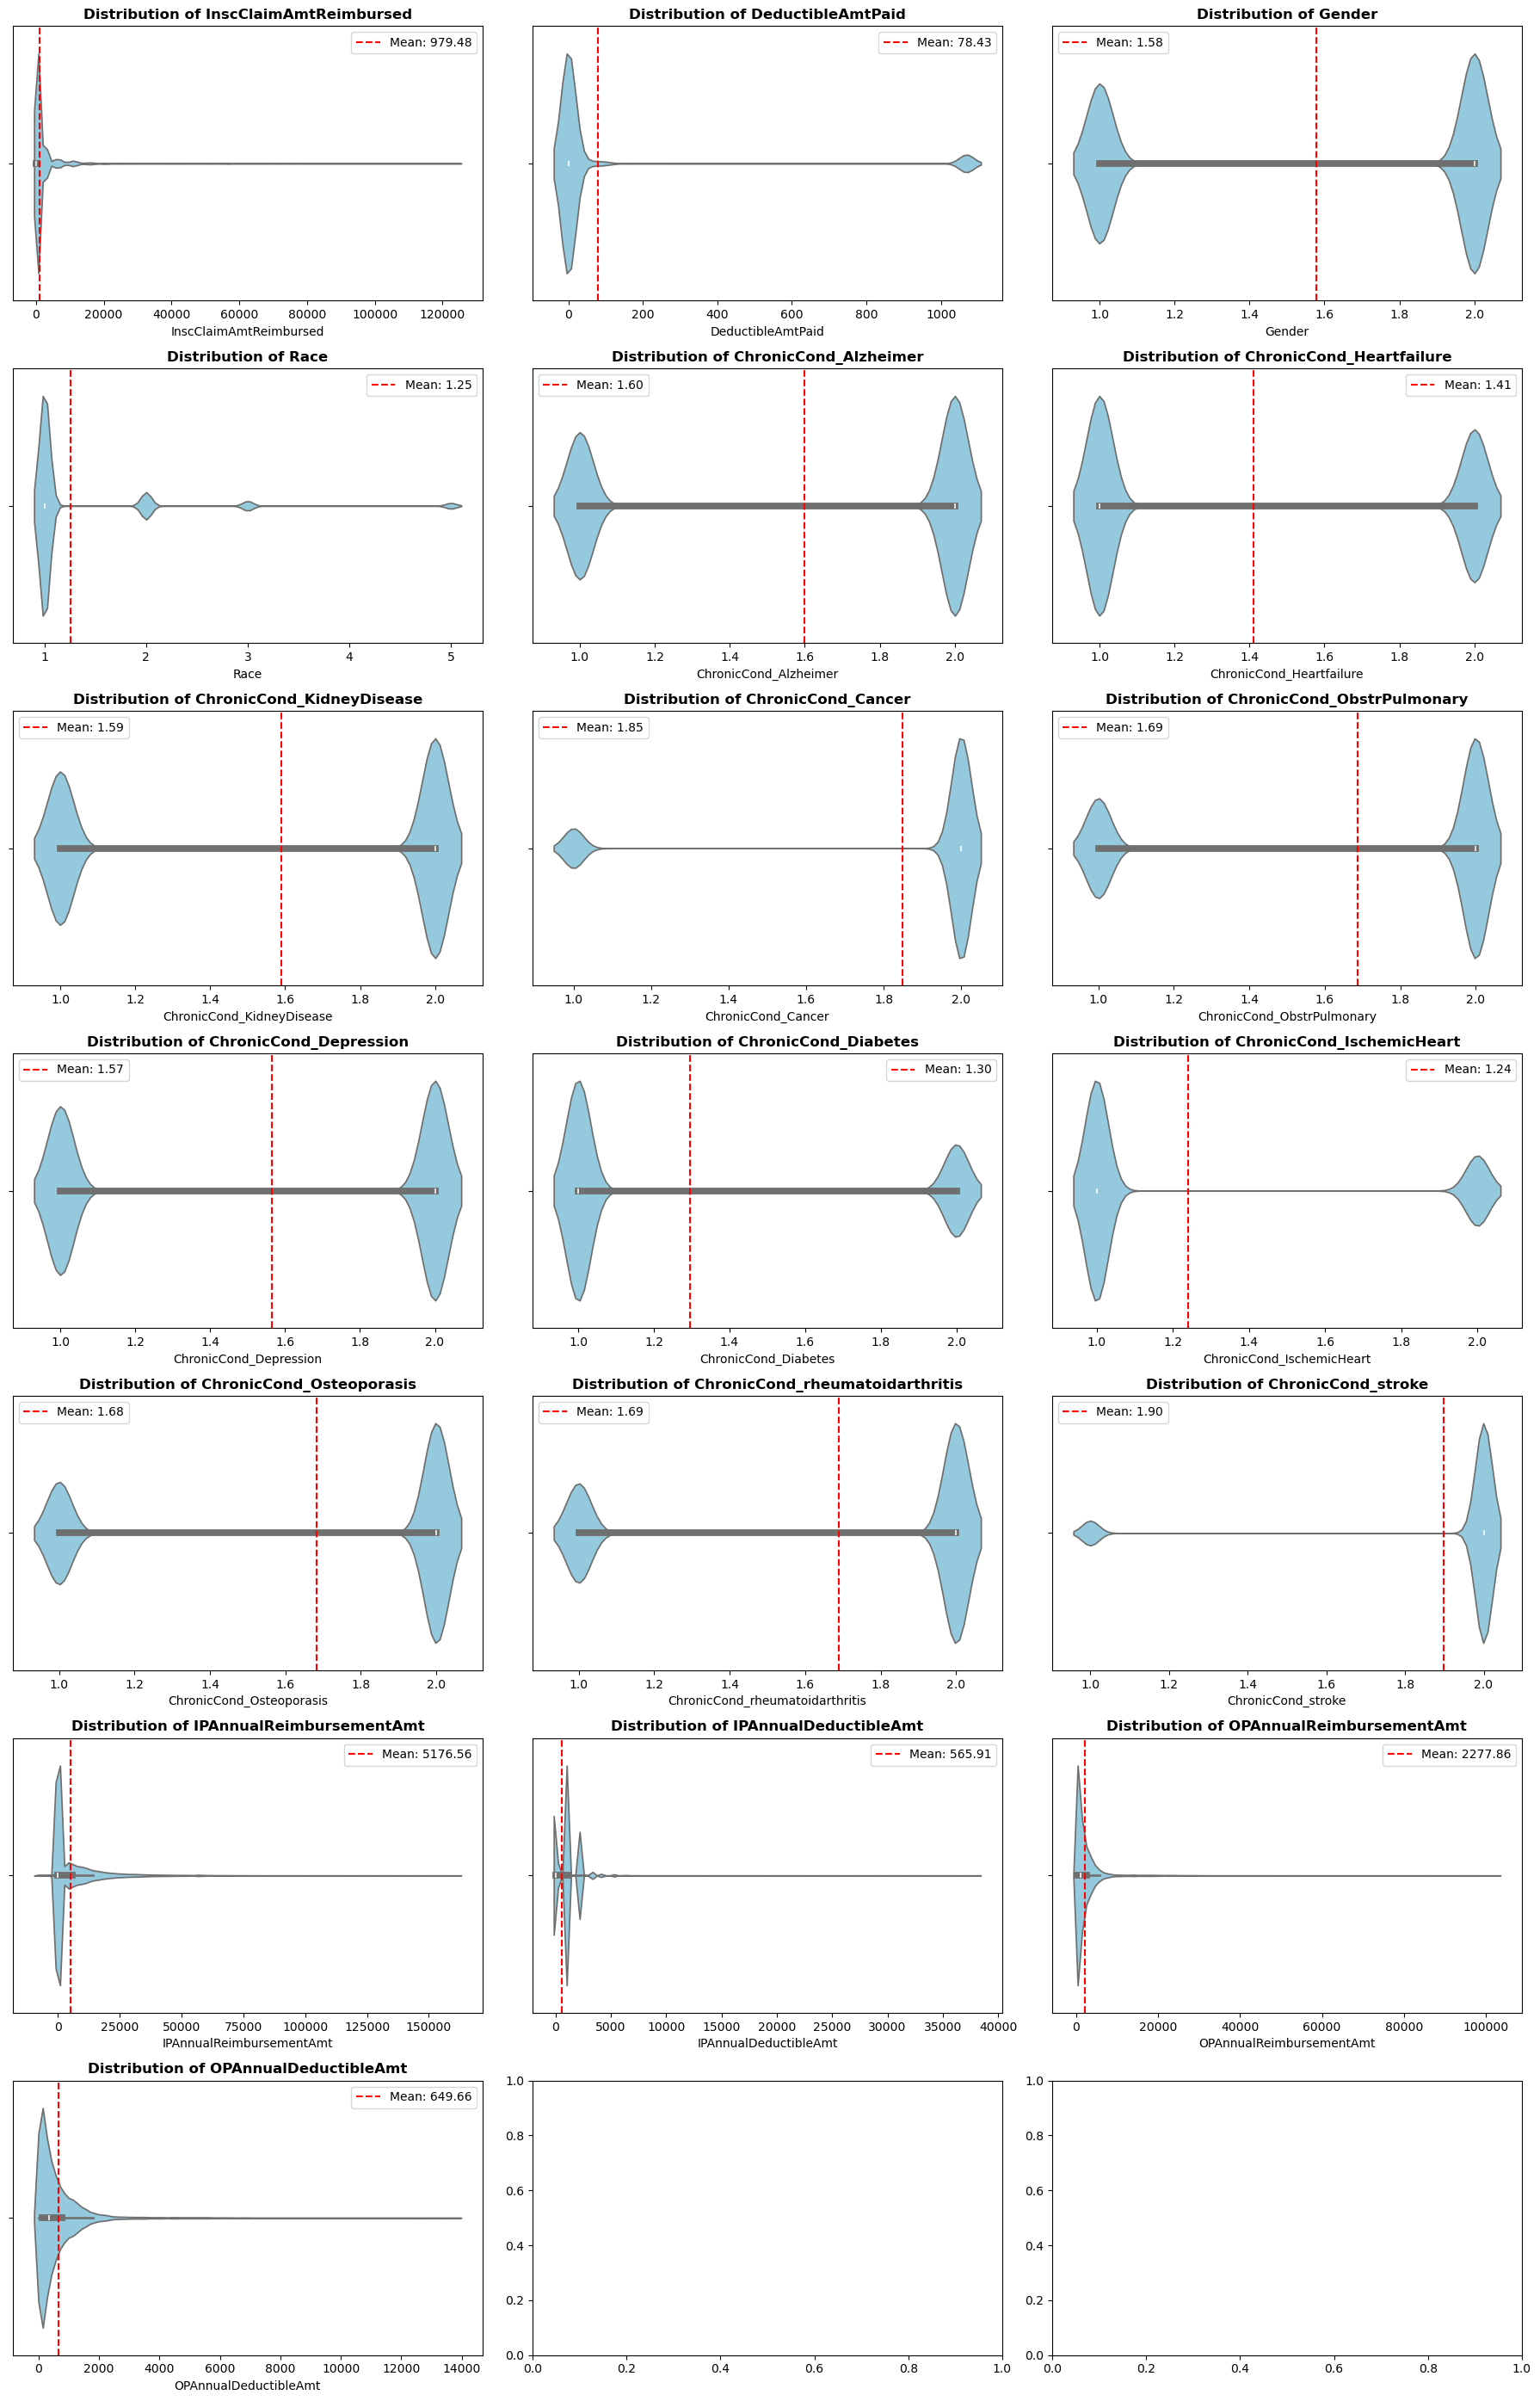

In [12]:
plot_cols = [col for col in df.select_dtypes(exclude='object').columns]
n_cols = len(plot_cols)

n_subplot_cols = 3
n_subplot_rows = math.ceil(n_cols / n_subplot_cols)

fig, axes = plt.subplots(n_subplot_rows, n_subplot_cols, figsize=(18, 4 * n_subplot_rows))
axes = axes.flatten()  

for i, col in enumerate(plot_cols):
    sns.violinplot(x=df[col].dropna(), ax=axes[i], color='skyblue', inner='box')
    
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

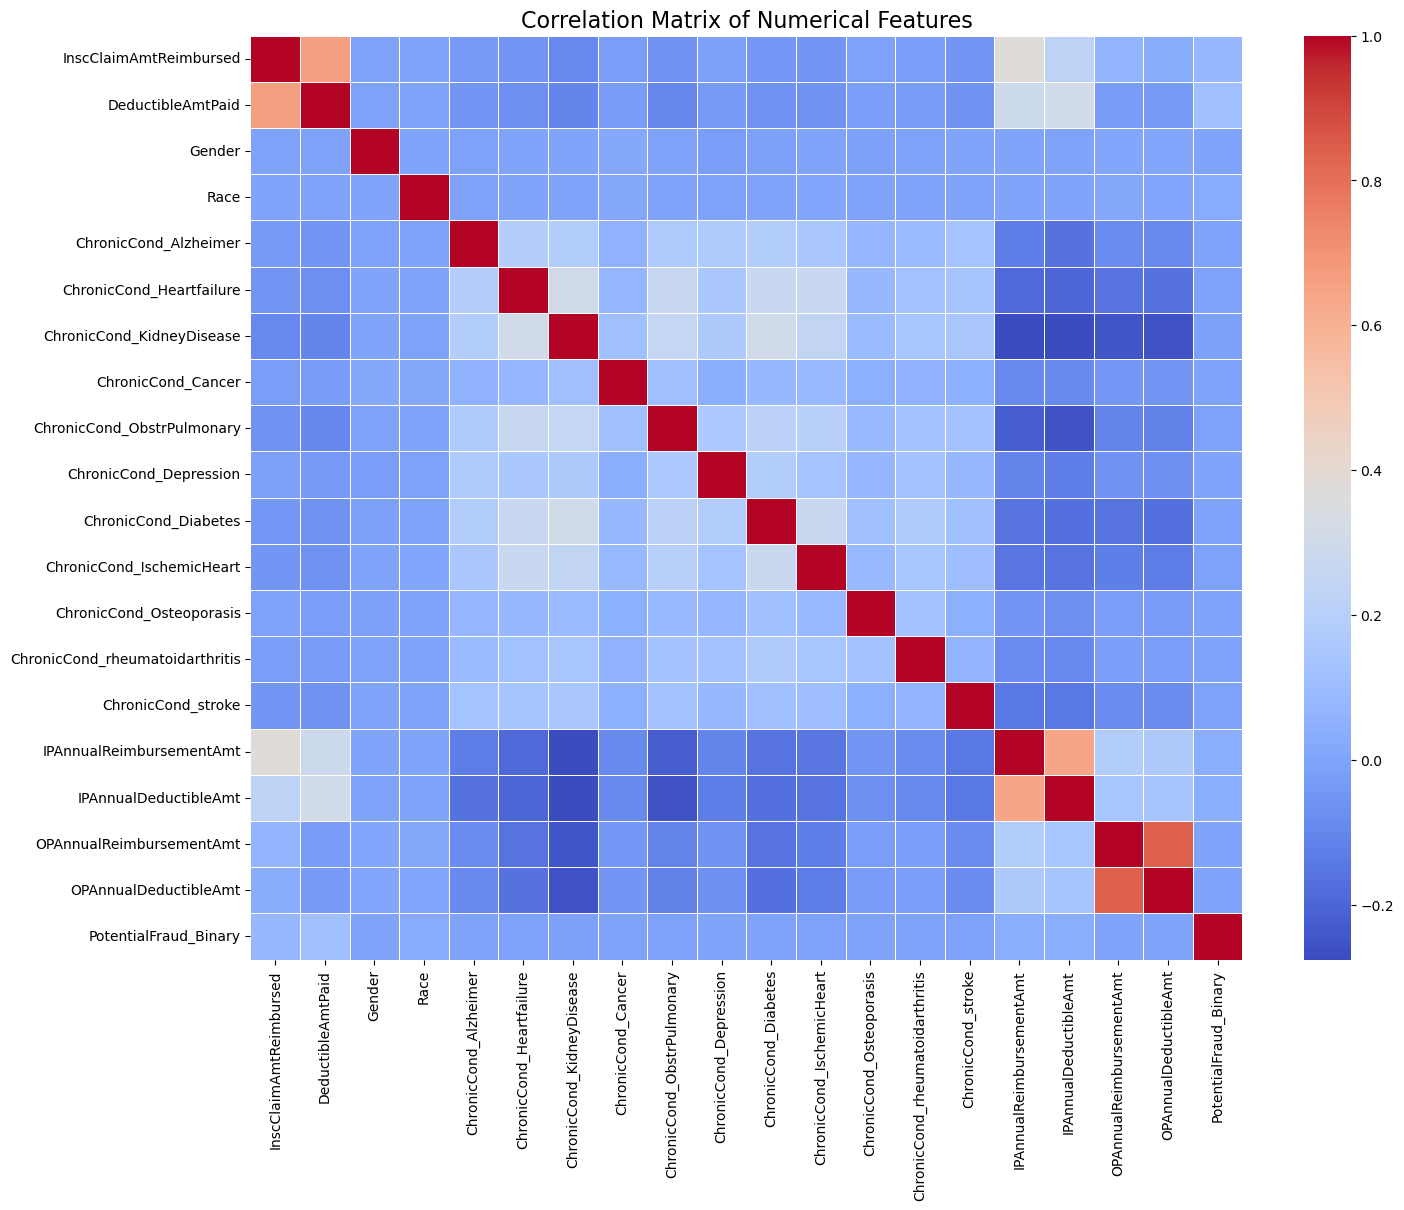

In [13]:
numeric_df = df.select_dtypes(include=['float64', 'int64']).copy()

if 'PotentialFraud' in df.columns:
    numeric_df['PotentialFraud_Binary'] = df['PotentialFraud'].apply(lambda x: 1 if x == 'Yes' else 0)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

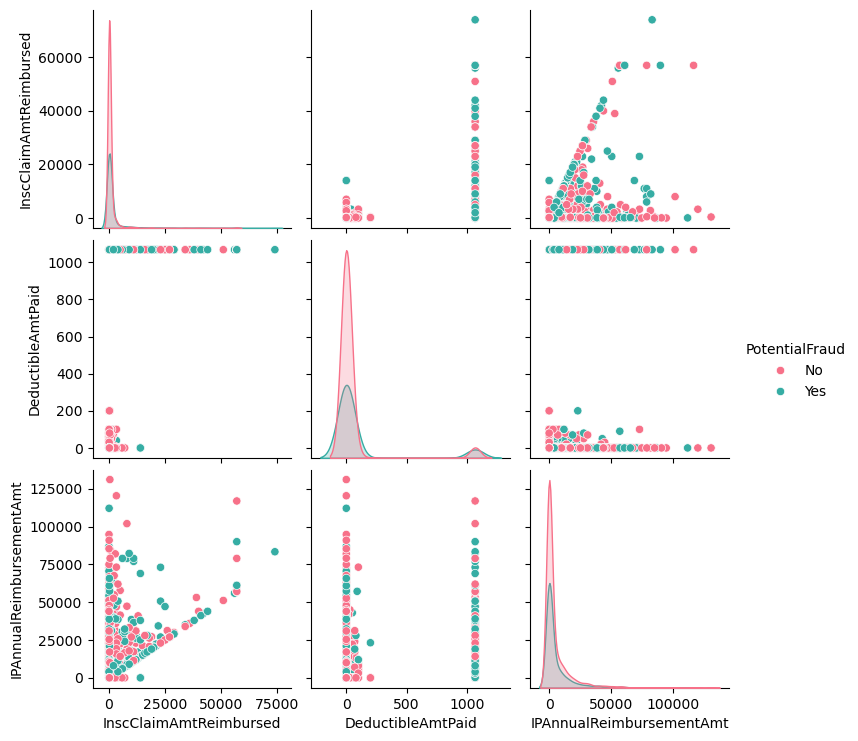

In [14]:
subset_cols = ['InscClaimAmtReimbursed', 'DeductibleAmtPaid', 
               'IPAnnualReimbursementAmt', 'NoOfMonths_PartACov', 'PotentialFraud']

subset_cols = [c for c in subset_cols if c in df.columns]

if len(subset_cols) > 1:
    sample_df = df[subset_cols].sample(n=min(5000, len(df)), random_state=42)
    sns.pairplot(sample_df, hue='PotentialFraud', diag_kind='kde', palette='husl')
    plt.show()

In [15]:
if df['PotentialFraud'].dtype == 'object':
    df['PotentialFraud'] = df['PotentialFraud'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['PotentialFraud'])
y = df['PotentialFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps=[ 
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ],
    verbose_feature_names_out=False  
)
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

X_train_final = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out())
X_test_final = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out())



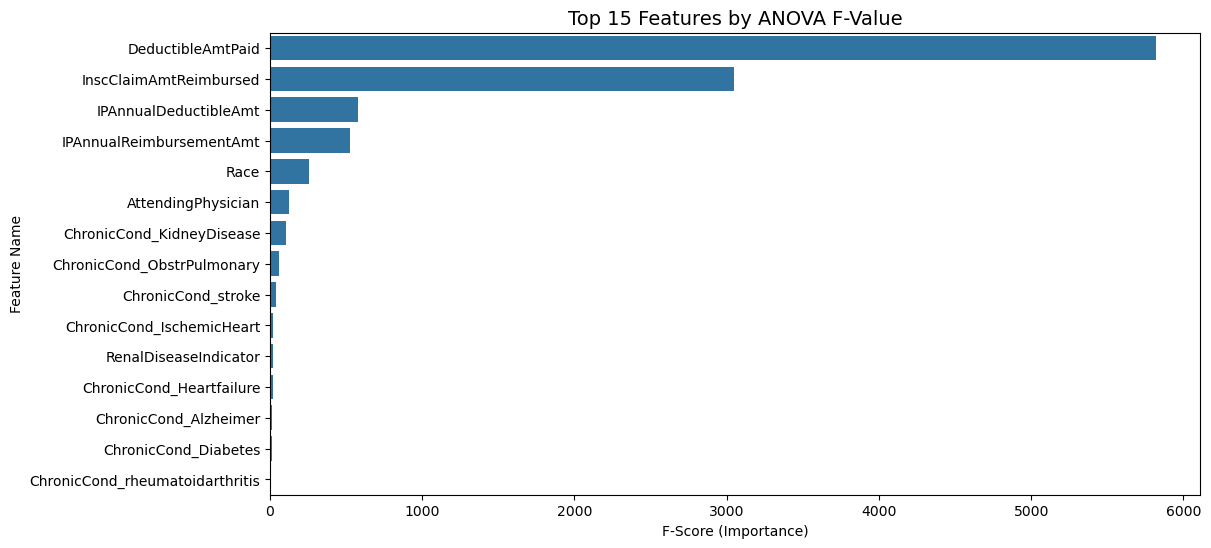

In [16]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif)

selector.fit(X_train_final, y_train)

selected_mask = selector.get_support()
selected_features = X_train_final.columns[selected_mask].tolist()

X_train_kbest = X_train_final[selected_features]
X_test_kbest = X_test_final[selected_features]


feature_scores = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Score': selector.scores_  
})

feature_scores = feature_scores.sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(15))
plt.title('Top 15 Features by ANOVA F-Value', fontsize=14)
plt.xlabel('F-Score (Importance)')
plt.ylabel('Feature Name')
plt.show()



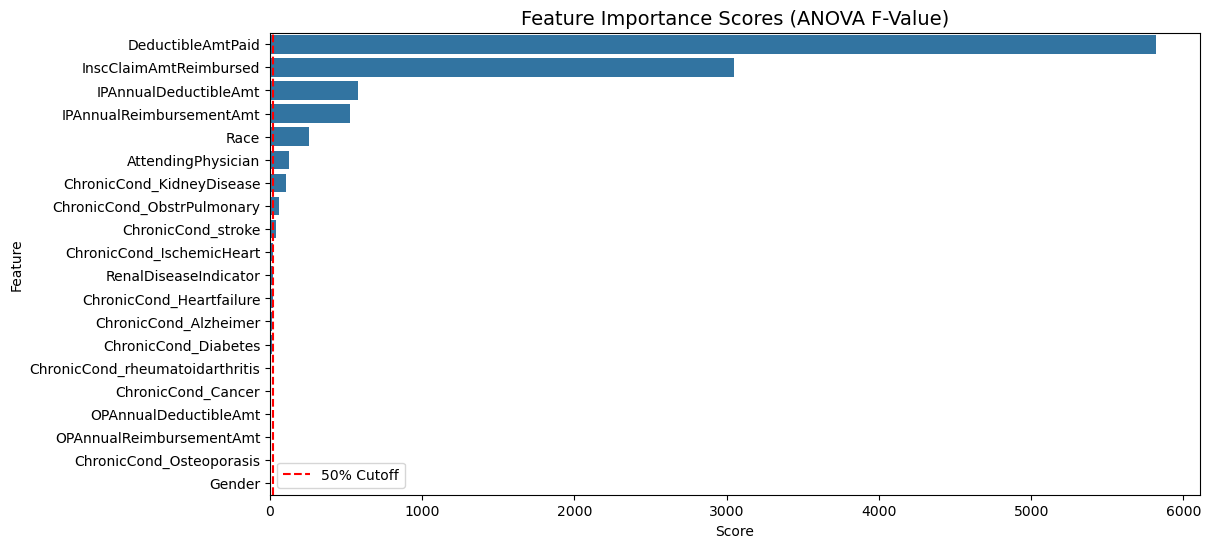

Original Feature Count: 21
Selected Feature Count (Top 50%): 10

Features Kept:
['InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'Race', 'ChronicCond_KidneyDisease', 'ChronicCond_ObstrPulmonary', 'ChronicCond_IschemicHeart', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'AttendingPhysician']


In [17]:
from sklearn.feature_selection import SelectPercentile, f_classif

selector_pct = SelectPercentile(score_func=f_classif, percentile=50)

selector_pct.fit(X_train_final, y_train)

selected_mask = selector_pct.get_support()
selected_features_pct = X_train_final.columns[selected_mask].tolist()

X_train_pct = selector_pct.transform(X_train_final)
X_test_pct = selector_pct.transform(X_test_final)

X_train_pct = pd.DataFrame(X_train_pct, columns=selected_features_pct)
X_test_pct = pd.DataFrame(X_test_pct, columns=selected_features_pct)

feature_scores = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Score': selector_pct.scores_
})

feature_scores = feature_scores.sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(20))
plt.title('Feature Importance Scores (ANOVA F-Value)', fontsize=14)
plt.axvline(x=feature_scores.iloc[len(selected_features_pct)-1]['Score'], color='r', linestyle='--', label='50% Cutoff')
plt.legend()
plt.show()

print(f"Original Feature Count: {X_train_final.shape[1]}")
print(f"Selected Feature Count (Top 50%): {X_train_pct.shape[1]}")
print("\nFeatures Kept:")
print(selected_features_pct)


Top 10 Features Selected by RFE:
                     Feature  Rank
0     InscClaimAmtReimbursed     1
1          DeductibleAmtPaid     1
2                     Gender     1
18     OPAnnualDeductibleAmt     1
4      ChronicCond_Alzheimer     1
17  OPAnnualReimbursementAmt     1
16     IPAnnualDeductibleAmt     1
15  IPAnnualReimbursementAmt     1
19        AttendingPhysician     1
12  ChronicCond_Osteoporasis     1


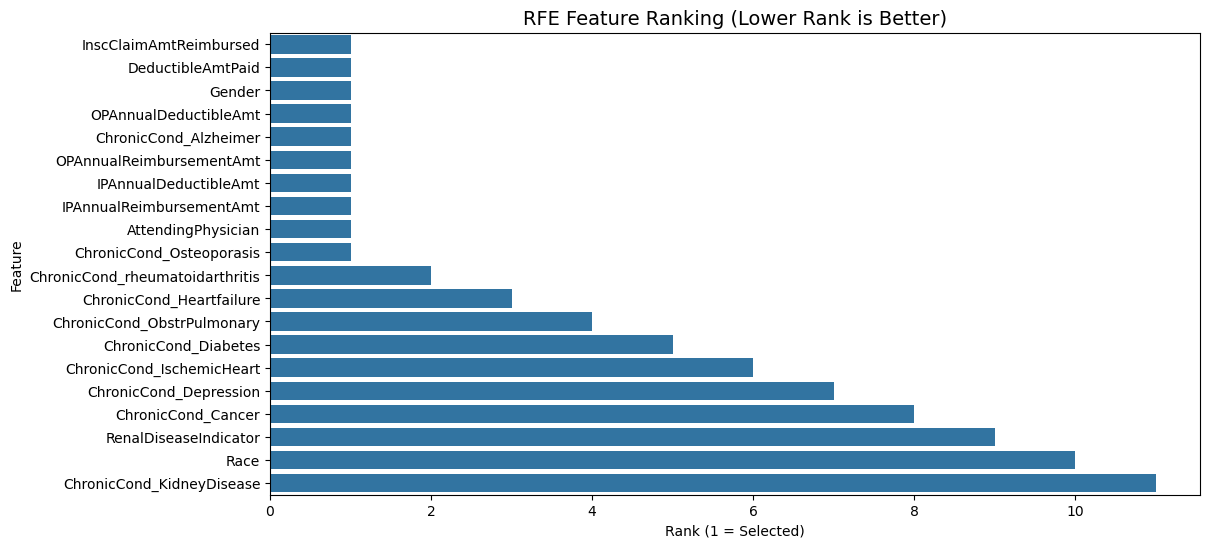

Original Feature Count: 21
RFE Selected Feature Count: 10


In [18]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rf, n_features_to_select=10, step=1)

rfe.fit(X_train_final, y_train)

selected_mask = rfe.support_
selected_features_rfe = X_train_final.columns[selected_mask].tolist()

X_train_rfe = X_train_final[selected_features_rfe]
X_test_rfe = X_test_final[selected_features_rfe]

rfe_ranking = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Rank': rfe.ranking_
})

rfe_ranking = rfe_ranking.sort_values(by='Rank')

print("\nTop 10 Features Selected by RFE:")
print(rfe_ranking[rfe_ranking['Rank'] == 1])

plt.figure(figsize=(12, 6))
sns.barplot(x='Rank', y='Feature', data=rfe_ranking.head(20))
plt.title('RFE Feature Ranking (Lower Rank is Better)', fontsize=14)
plt.xlabel('Rank (1 = Selected)')
plt.show()

print(f"Original Feature Count: {X_train_final.shape[1]}")
print(f"RFE Selected Feature Count: {X_train_rfe.shape[1]}")

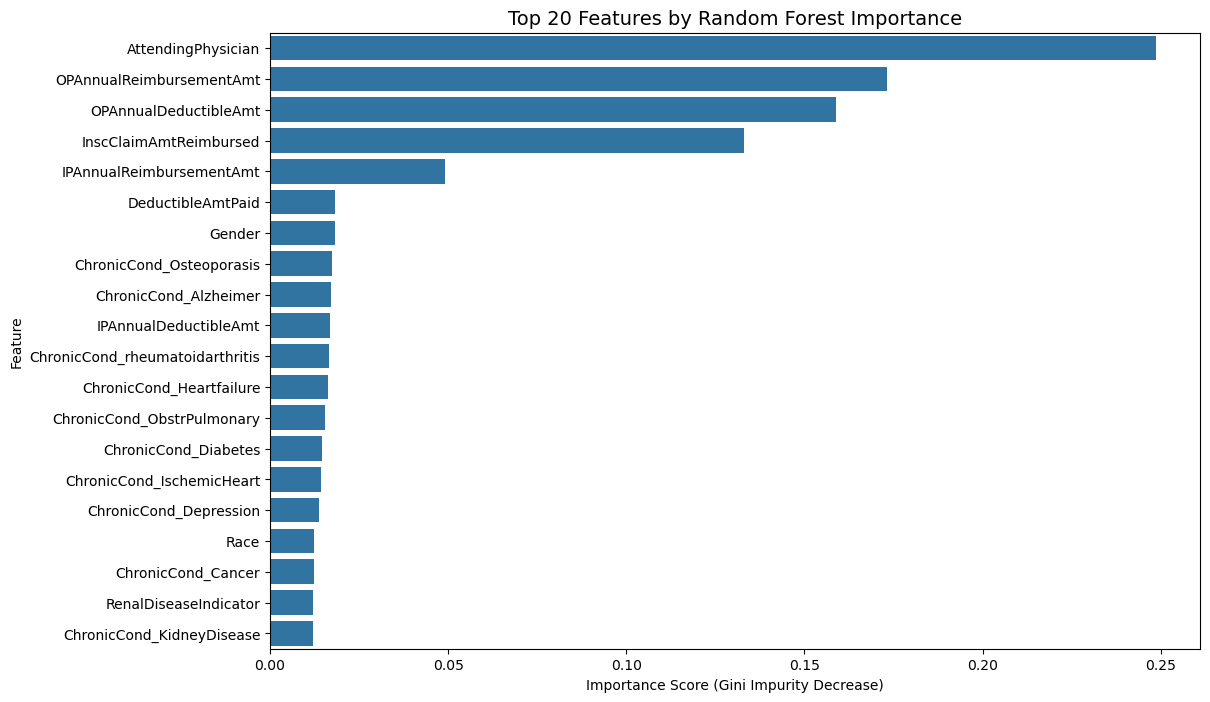

C:\Users\heman\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\heman\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Original Feature Count: 21
Selected Feature Count: 5

Top 10 Selected Features:
['InscClaimAmtReimbursed', 'IPAnnualReimbursementAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'AttendingPhysician']


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_final, y_train)

importances = rf.feature_importances_
feature_names = X_train_final.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Features by Random Forest Importance', fontsize=14)
plt.xlabel('Importance Score (Gini Impurity Decrease)')
plt.show()

selector = SelectFromModel(rf, threshold='mean', prefit=True)

X_train_tree = selector.transform(X_train_final)
X_test_tree = selector.transform(X_test_final)

selected_mask = selector.get_support()
selected_features_tree = X_train_final.columns[selected_mask].tolist()

print(f"Original Feature Count: {X_train_final.shape[1]}")
print(f"Selected Feature Count: {X_train_tree.shape[1]}")
print(f"\nTop 10 Selected Features:\n{selected_features_tree[:10]}")

In [20]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

sfs = SequentialFeatureSelector(dt, 
                                n_features_to_select=10, 
                                direction='forward',
                                scoring='roc_auc',
                                cv=3,
                                n_jobs=-1)

sfs.fit(X_train_final, y_train)

selected_mask = sfs.get_support()
selected_features_sfs = X_train_final.columns[selected_mask].tolist()

X_train_sfs = sfs.transform(X_train_final)
X_test_sfs = sfs.transform(X_test_final)

X_train_sfs = pd.DataFrame(X_train_sfs, columns=selected_features_sfs)

print(f"Original Feature Count: {X_train_final.shape[1]}")
print(f"Selected Feature Count: {X_train_sfs.shape[1]}")
print("\nTop 10 Features Selected by SFS:")
print(selected_features_sfs)

Original Feature Count: 21
Selected Feature Count: 10

Top 10 Features Selected by SFS:
['DeductibleAmtPaid', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'AttendingPhysician', 'RenalDiseaseIndicator']


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

X = df.drop(columns=['PotentialFraud'])
y = df['PotentialFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ],
    verbose_feature_names_out=False  
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [22]:
with open ("preprocessor.pkl",'wb') as f:
    pickle.dump(preprocessor,f)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_trans, y_train)

y_pred = knn.predict(X_test_trans)

print("\n" + "="*40)
print("KNN MODEL PERFORMANCE")
print("="*40)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


KNN MODEL PERFORMANCE
Accuracy: 0.8947

Confusion Matrix:
[[64263  4554]
 [ 7152 35194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     68817
           1       0.89      0.83      0.86     42346

    accuracy                           0.89    111163
   macro avg       0.89      0.88      0.89    111163
weighted avg       0.89      0.89      0.89    111163



In [24]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_trans, y_train)

y_pred_nb = nb_model.predict(X_test_trans)

print("\n" + "="*40)
print("NAIVE BAYES MODEL PERFORMANCE")
print("="*40)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy: {accuracy_nb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


NAIVE BAYES MODEL PERFORMANCE
Accuracy: 0.6228

Confusion Matrix:
[[63681  5136]
 [36794  5552]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.93      0.75     68817
           1       0.52      0.13      0.21     42346

    accuracy                           0.62    111163
   macro avg       0.58      0.53      0.48    111163
weighted avg       0.59      0.62      0.55    111163



In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_trans, y_train)

y_pred_dt = dt_model.predict(X_test_trans)

print("\n" + "="*40)
print("DECISION TREE PERFORMANCE")
print("="*40)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy_dt:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


DECISION TREE PERFORMANCE
Accuracy: 0.9102

Confusion Matrix:
[[63815  5002]
 [ 4984 37362]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     68817
           1       0.88      0.88      0.88     42346

    accuracy                           0.91    111163
   macro avg       0.90      0.90      0.90    111163
weighted avg       0.91      0.91      0.91    111163



In [26]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_trans, y_train)

y_pred_log = log_reg.predict(X_test_trans)

print("\n" + "="*40)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*40)

accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy: {accuracy_log:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


LOGISTIC REGRESSION PERFORMANCE
Accuracy: 0.6290

Confusion Matrix:
[[65400  3417]
 [37824  4522]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.95      0.76     68817
           1       0.57      0.11      0.18     42346

    accuracy                           0.63    111163
   macro avg       0.60      0.53      0.47    111163
weighted avg       0.61      0.63      0.54    111163



C:\Users\heman\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
# from sklearn.svm import SVC

# svc_model = SVC(kernel='rbf', random_state=42)


# svc_model.fit(X_train_trans, y_train)

# y_pred_svc = svc_model.predict(X_test_trans)

# print("\n" + "="*40)
# print("SVC MODEL PERFORMANCE")
# print("="*40)

# accuracy_svc = accuracy_score(y_test, y_pred_svc)
# print(f"Accuracy: {accuracy_svc:.4f}")

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred_svc))

# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_svc))

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_trans, y_train)

y_pred_rf = rf_clf.predict(X_test_trans)

print("RANDOM FOREST PERFORMANCE")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))


RANDOM FOREST PERFORMANCE
Accuracy: 0.7084
              precision    recall  f1-score   support

           0       0.71      0.89      0.79     68817
           1       0.69      0.42      0.52     42346

    accuracy                           0.71    111163
   macro avg       0.70      0.65      0.66    111163
weighted avg       0.71      0.71      0.69    111163



In [29]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(),
                                n_estimators=100,
                                random_state=42,
                                n_jobs=-1)

bagging_clf.fit(X_train_trans, y_train)

y_pred_bag = bagging_clf.predict(X_test_trans)

print("BAGGING PERFORMANCE")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}")
print(classification_report(y_test, y_pred_bag))

BAGGING PERFORMANCE
Accuracy: 0.9282
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     68817
           1       0.95      0.86      0.90     42346

    accuracy                           0.93    111163
   macro avg       0.93      0.92      0.92    111163
weighted avg       0.93      0.93      0.93    111163



In [30]:
with open ("model.pkl",'wb') as f:
    pickle.dump(bagging_clf,f)

In [31]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_clf.fit(X_train_trans, y_train)

gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_clf.fit(X_train_trans, y_train)

print("BOOSTING PERFORMANCE")
print("="*40)
print(f"AdaBoost Accuracy:       {accuracy_score(y_test, ada_clf.predict(X_test_trans)):.4f}")
print(f"Gradient Boost Accuracy: {accuracy_score(y_test, gb_clf.predict(X_test_trans)):.4f}")

BOOSTING PERFORMANCE
AdaBoost Accuracy:       0.6329
Gradient Boost Accuracy: 0.6758


In [32]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

clf1 = LogisticRegression(random_state=42, max_iter=1000)
clf2 = RandomForestClassifier(n_estimators=50, random_state=42)
clf3 = KNeighborsClassifier(n_neighbors=5)

voting_clf = VotingClassifier(estimators=[
    ('lr', clf1), ('rf', clf2), ('knn', clf3)],
    voting='soft')

voting_clf.fit(X_train_trans, y_train)

y_pred_vote = voting_clf.predict(X_test_trans)

print("VOTING CLASSIFIER PERFORMANCE")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_vote):.4f}")
print(classification_report(y_test, y_pred_vote))

C:\Users\heman\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VOTING CLASSIFIER PERFORMANCE
Accuracy: 0.8830
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     68817
           1       0.93      0.75      0.83     42346

    accuracy                           0.88    111163
   macro avg       0.90      0.86      0.87    111163
weighted avg       0.89      0.88      0.88    111163



In [33]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stacking_clf = StackingClassifier(
    estimators=estimators, 
    final_estimator=LogisticRegression(),
    cv=3  
)

stacking_clf.fit(X_train_trans, y_train)

y_pred_stack = stacking_clf.predict(X_test_trans)

print("STACKING CLASSIFIER PERFORMANCE")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}")
print(classification_report(y_test, y_pred_stack))

STACKING CLASSIFIER PERFORMANCE
Accuracy: 0.8969
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     68817
           1       0.90      0.82      0.86     42346

    accuracy                           0.90    111163
   macro avg       0.90      0.88      0.89    111163
weighted avg       0.90      0.90      0.90    111163



In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth': [i for i in range(5,20)]+[None],
    'min_samples_split': [i for i in range(5,20)],
    'min_samples_leaf': [i for i in range(5,20)],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2',None]
}

dt_model = DecisionTreeClassifier(random_state=42)
random_search = RandomizedSearchCV(
    dt_model, param_distributions=param_dist, n_iter=50, 
    cv=5, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train_trans, y_train)

best_dt = random_search.best_estimator_
print(f"Best params: {random_search.best_params_}")
print(f"Best CV accuracy: {random_search.best_score_:.4f}")

y_pred_dt = best_dt.predict(X_test_trans)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("TUNED DECISION TREE PERFORMANCE")
print("="*40)
print(f"Accuracy: {accuracy_dt:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': None, 'criterion': 'gini'}
Best CV accuracy: 0.9088
TUNED DECISION TREE PERFORMANCE
Accuracy: 0.9214

Confusion Matrix:
[[65768  3049]
 [ 5687 36659]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     68817
           1       0.92      0.87      0.89     42346

    accuracy                           0.92    111163
   macro avg       0.92      0.91      0.92    111163
weighted avg       0.92      0.92      0.92    111163



In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(50, 200), 
    'max_samples': uniform(0.5, 0.4),  
    'max_features': [0.8, 0.9, 1.0],
    'bootstrap': [True, False],
    'estimator__max_depth': [3, 5, 10, 15, None],  
    'estimator__min_samples_split': randint(2, 20),
    'estimator__min_samples_leaf': randint(1, 10),
    'estimator__criterion': ['gini', 'entropy']
}

base_dt = DecisionTreeClassifier(random_state=42)
bagging_clf = BaggingClassifier(estimator=base_dt, random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    bagging_clf, param_distributions=param_dist, n_iter=50,
    cv=5, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train_trans, y_train)

best_bag = random_search.best_estimator_
print(f"Best params: {random_search.best_params_}")
print(f"Best CV accuracy: {random_search.best_score_:.4f}")

y_pred_bag = best_bag.predict(X_test_trans)
print("TUNED BAGGING PERFORMANCE")
print("="*40)
print(f"Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}")
print(classification_report(y_test, y_pred_bag))


Fitting 5 folds for each of 50 candidates, totalling 250 fits


In [21]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: C:\Users\heman\AppData\Roaming\Python\Python312\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: imbalanced-learn, sentence-transformers, sklearn-extensions, sklearn-genetic


In [20]:
!pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 1.5 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.0 MB 1.7 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.0 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.3/8.0 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.0 MB 1.4 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/8.0 MB 1.4 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.0 MB 1.5 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.0 MB 1.6 MB/s eta 0:00:04
   ---------------- ----------------------- 3.4/8.0 MB 1.8 MB/s eta 0:00:03
   ------------------- --------

  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
